In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\rajem\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df=pd.read_csv("Algerian_forest_fires_dataset.csv",header=0)

In [3]:
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
243,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
244,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
245,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [4]:
df = df.drop(df.index[[122, 123,124]])

In [5]:
df.columns=df.columns.str.strip()

In [6]:
df=df.reset_index(drop=True)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          244 non-null    str  
 1   month        244 non-null    str  
 2   year         244 non-null    str  
 3   Temperature  244 non-null    str  
 4   RH           244 non-null    str  
 5   Ws           244 non-null    str  
 6   Rain         244 non-null    str  
 7   FFMC         244 non-null    str  
 8   DMC          244 non-null    str  
 9   DC           244 non-null    str  
 10  ISI          244 non-null    str  
 11  BUI          244 non-null    str  
 12  FWI          244 non-null    str  
 13  Classes      243 non-null    str  
dtypes: str(14)
memory usage: 37.6 KB


In [8]:
df.loc[:122,"Region"]=0
df.loc[122:,"Region"]=1

In [9]:
df[['Region']]=df[['Region']].astype(int)

In [10]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [11]:
df[["day", "month", "year", "Temperature", "RH", "Ws", "Region"]]=df[["day", "month", "year", "Temperature", "RH", "Ws", "Region"]].astype(int)

In [12]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          244 non-null    int64
 1   month        244 non-null    int64
 2   year         244 non-null    int64
 3   Temperature  244 non-null    int64
 4   RH           244 non-null    int64
 5   Ws           244 non-null    int64
 6   Rain         244 non-null    str  
 7   FFMC         244 non-null    str  
 8   DMC          244 non-null    str  
 9   DC           244 non-null    str  
 10  ISI          244 non-null    str  
 11  BUI          244 non-null    str  
 12  FWI          244 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       244 non-null    int64
dtypes: int64(7), str(8)
memory usage: 36.3 KB


In [14]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [15]:
for col in ["FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]:
    df[col] = df[col].astype(str).str.strip()

In [16]:
# 2. Convert to numeric, forcing text anomalies into NaN values safely
for col in ["FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [17]:
# 3. Drop the rows containing those broken text artifacts
df = df.dropna(subset=["FFMC", "DMC", "DC", "ISI", "BUI", "FWI"])

In [18]:
# 4. Cleanly convert the valid numbers to floats
df[["FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]] = df[
    ["FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]
].astype(float)

In [19]:
# 5. Reset your row indices cleanly
df = df.reset_index(drop=True)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    str    
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  Region       243 non-null    int64  
dtypes: float64(6), int64(7), str(2)
memory usage: 31.2 KB


In [21]:
df['Rain']=df['Rain'].astype(float)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), str(1)
memory usage: 30.7 KB


In [23]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [24]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), str(1)
memory usage: 30.7 KB


In [26]:
df.to_csv('Algerian_forest_cleaned.csv',index=False)

In [27]:
## eDA

In [28]:
df_copy=df.drop(['day',"month",'year'],axis=1)

In [29]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [30]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  243 non-null    int64  
 1   RH           243 non-null    int64  
 2   Ws           243 non-null    int64  
 3   Rain         243 non-null    float64
 4   FFMC         243 non-null    float64
 5   DMC          243 non-null    float64
 6   DC           243 non-null    float64
 7   ISI          243 non-null    float64
 8   BUI          243 non-null    float64
 9   FWI          243 non-null    float64
 10  Classes      243 non-null    str    
 11  Region       243 non-null    int64  
dtypes: float64(7), int64(4), str(1)
memory usage: 25.0 KB


In [31]:
df_copy=df['Classes'].astype(object)

In [32]:
# 1. Create a clean, separate copy of your working DataFrame
df_copy = df.copy()

# 2. Strip hidden spaces from the 'Classes' column text first
# This fixes rows that say 'not fire ' or 'fire  ' with trailing spaces
df_copy["Classes"] = df_copy["Classes"].astype(str).str.strip()

# 3. Encode the column: 'not fire' becomes 0, everything else (fire) becomes 1
df_copy["Classes"] = np.where(df_copy["Classes"] == "not fire", 0, 1)

# 4. View your clean table to verify
df_copy.head()


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [33]:
df_copy=df.drop(['day',"month",'year'],axis=1)

In [34]:
df_copy.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire,1


In [35]:
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

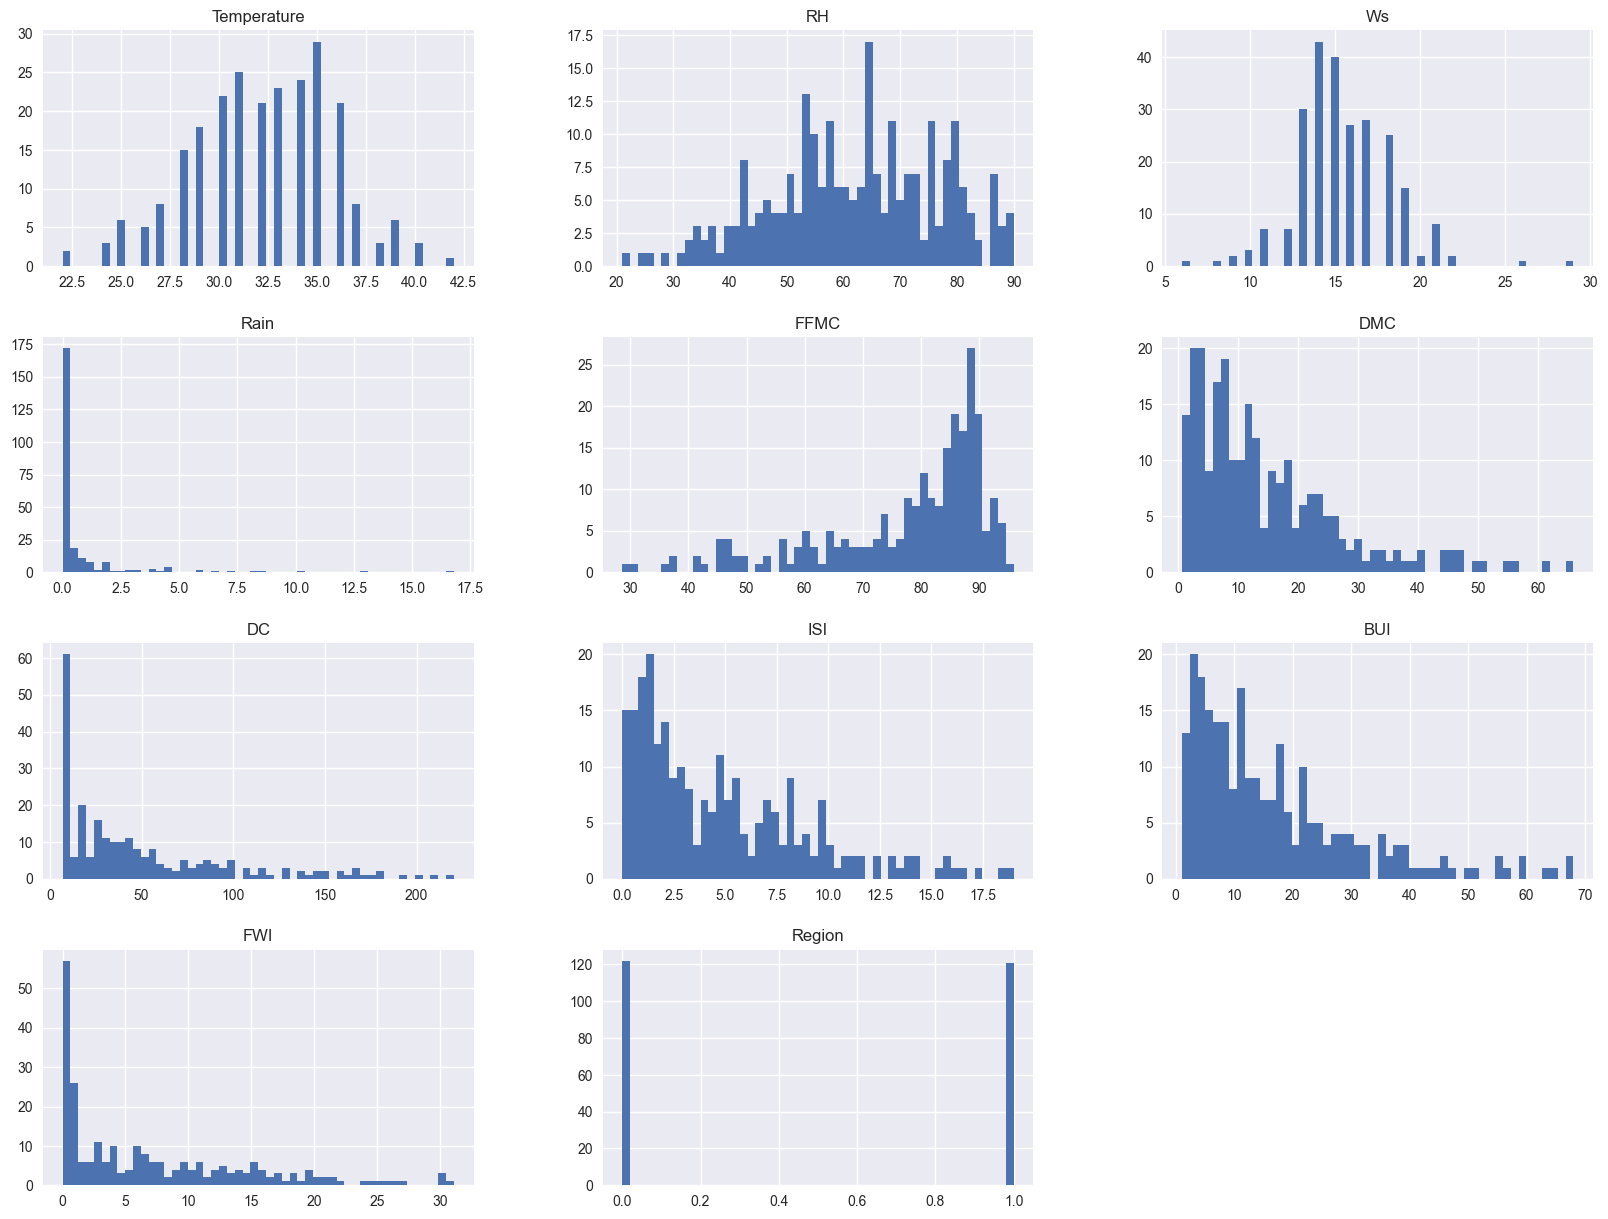

In [36]:
plt.style.use('seaborn-v0_8')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

In [37]:
df_copy['Classes'] = df_copy['Classes'].str.strip()

In [38]:
percentages=df_copy['Classes'].value_counts(normalize=True)*100

([<matplotlib.patches.Wedge at 0x213e09934d0>,
 [Text(-0.2189564657232264, 1.0779879712306597, 'fire'),
  Text(0.21895655996393085, -1.0779879520888727, 'not fire')],
 [Text(-0.11943079948539621, 0.5879934388530871, '56.4%'),
  Text(0.11943085088941681, -0.5879934284121123, '43.6%')])

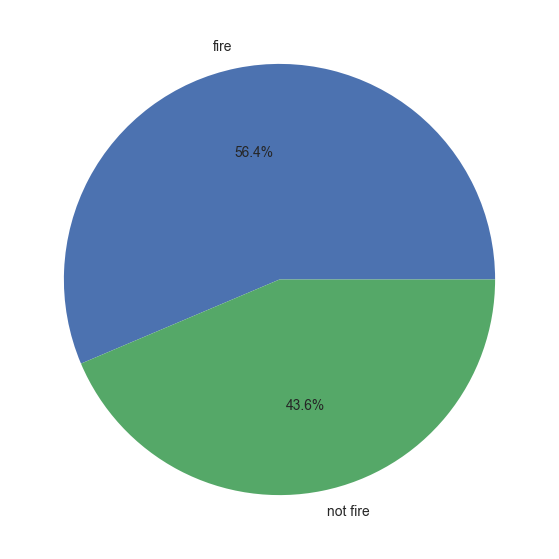

In [39]:
classlabels=['fire','not fire']
plt.figure(figsize=(12,7))
plt.pie(percentages,labels=classlabels,autopct='%1.1f%%',)

In [40]:
# 1. Create a clean, separate copy of your dataset
df_copy = df.copy()

# 2. Convert to string and force lowercase to prevent casing errors
df_copy["Classes"] = df_copy["Classes"].astype(str).str.lower()

# 3. DYNAMIC ENCODING: If it contains the phrase "not fire", it becomes 0. Otherwise 1.
# (case=False ignores capitalizations, and na=False handles empty cells safely)
df_copy["Classes"] = np.where(df_copy["Classes"].str.contains("not fire", case=False, na=False), 0, 1)

# 4. CHECK YOUR WORK: Print counts to make sure it split into 0s and 1s perfectly
print(df_copy["Classes"].value_counts())


Classes
1    137
0    106
Name: count, dtype: int64


In [41]:
corr=df_copy.corr()

<Axes: >

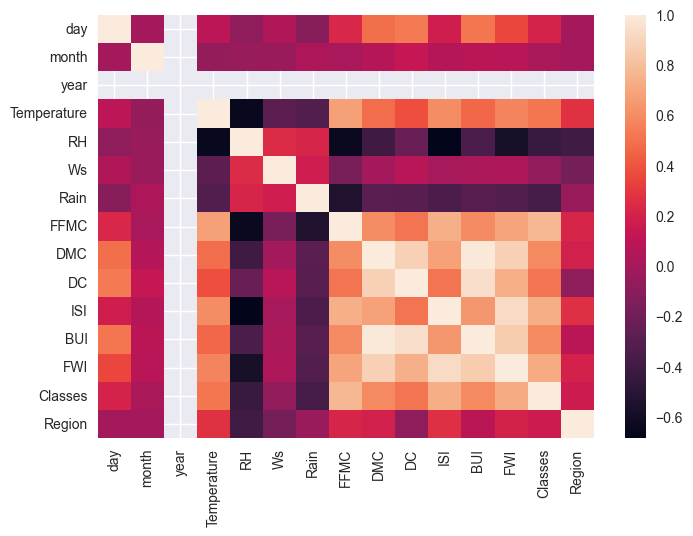

In [42]:
sns.heatmap(data=corr,)

<Axes: ylabel='FWI'>

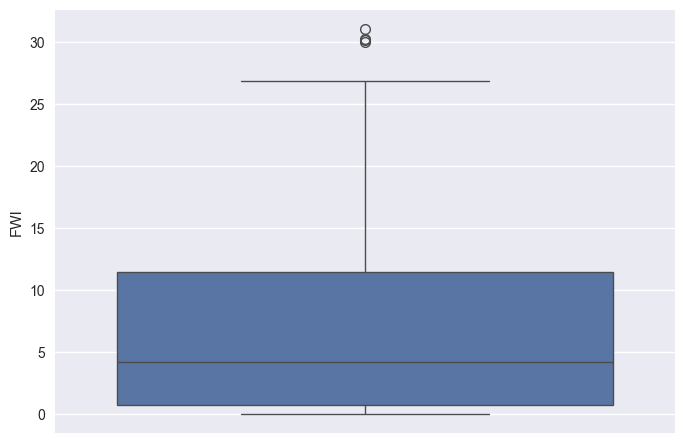

In [43]:
## boxplot
sns.boxplot(df_copy['FWI'])

Text(0, 0.5, 'number of fires')

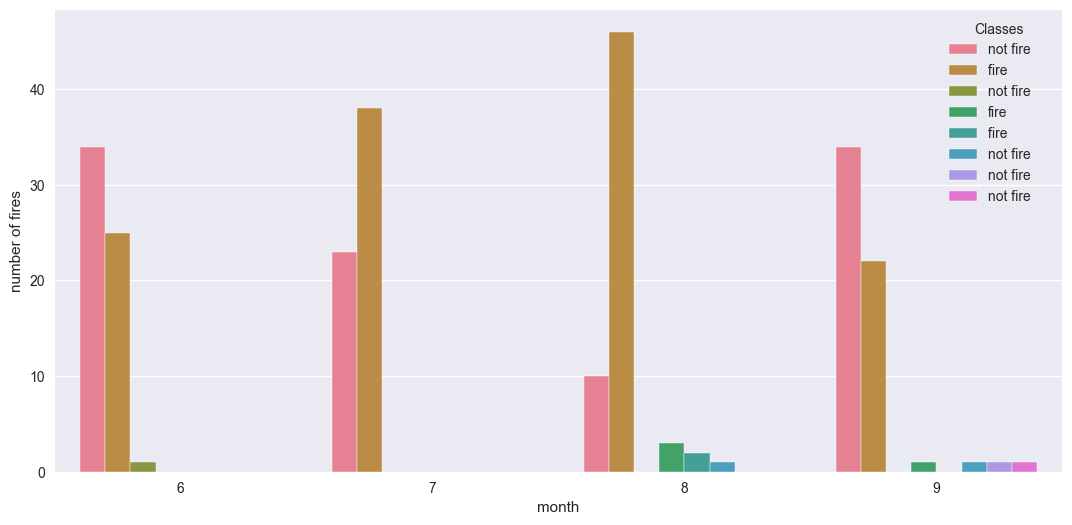

In [44]:
## monthly fire analysis
dftemp=df.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.ylabel("number of fires")

Text(0, 0.5, 'number of fires')

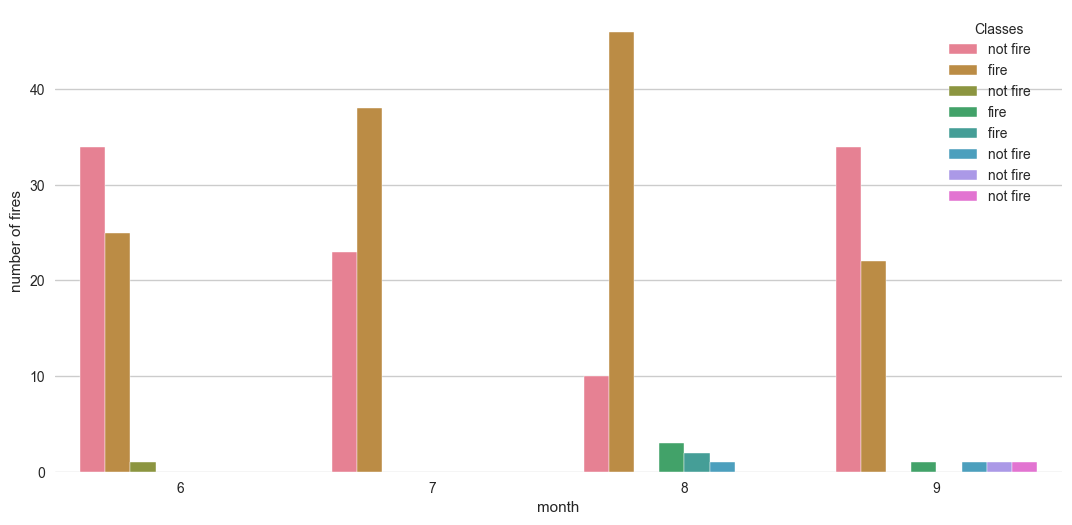

In [45]:
## monthly fire analysis
dftemp=df.loc[df['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.ylabel("number of fires")